# PCA Reconstruction Anomaly Detection

This notebook uses **PCA reconstruction error** to detect anomalies in spectra data, following the same workflow as the other model notebooks.

**Core idea:**
- PCA is fit exclusively on `all_spectra.csv` (normal samples), finding the directions of greatest variance — the **principal components**
- Each spectrum is projected into a lower-dimensional subspace spanned by the top `N_COMPONENTS` components, then **reconstructed** back to the original 535-dimensional space
- Because the subspace was learned from normal spectra, normal samples reconstruct accurately
- **Anomalous spectra** do not lie in this subspace, so they reconstruct poorly — yielding a **high reconstruction error**
- The **anomaly score** is the **mean squared error (MSE)** between the original and reconstructed spectrum

**Advantage over the Autoencoder:** PCA is linear, deterministic, and has no risk of overfitting. It serves as a strong, interpretable baseline for reconstruction-based anomaly detection.

**Goal:** Evaluate whether PCA reconstruction error can correctly identify `ambient_spectra.csv` particles as anomalies.

## 1. Hyperparameters

All settings are defined here so you can experiment without hunting through the code.

| Parameter | Description |
|-----------|-------------|
| `N_COMPONENTS` | Number of principal components to keep. Controls how much variance the subspace captures. More components = better reconstruction of normal samples but also better reconstruction of anomalies (less sensitive). Fewer = more compression, higher error for anything not well-represented by normal data. |
| `THRESHOLD_PERCENTILE` | Percentile of normal training reconstruction errors used as the decision threshold. Scores above this are flagged as anomalies. |

In [ ]:
# ── Tune these values to experiment with the model ──────────────────────────

N_COMPONENTS         = 50   # number of principal components to retain
THRESHOLD_PERCENTILE = 95   # percentile of normal training scores used as decision threshold

# ─────────────────────────────────────────────────────────────────────────────

print(f'N_COMPONENTS         = {N_COMPONENTS}')
print(f'THRESHOLD_PERCENTILE = {THRESHOLD_PERCENTILE}')

## 2. Imports

Loading all libraries needed for data handling, PCA, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

np.random.seed(42)

## 3. Load Data

- `all_spectra.csv` → **normal** particles. PCA is fit exclusively on these.
- `ambient_spectra.csv` → **anomaly** particles. Only used at evaluation time — the model never sees them during training.

Only the wavelength intensity columns are used as features. The `polymer` label column is dropped.

In [ ]:
# Load both datasets
all_spectra     = pd.read_csv('../data/all_spectra.csv',     index_col=0)
ambient_spectra = pd.read_csv('../data/ambient_spectra.csv', index_col=0)

# Identify the label column and keep only wavelength columns as features
label_col   = 'polymer'
wavelengths = [c for c in all_spectra.columns if c != label_col]

# Feature matrices — rows = samples, columns = wavelength intensities
X_normal  = all_spectra[wavelengths].values      # shape: (1215, 535)
X_anomaly = ambient_spectra[wavelengths].values  # shape: (55, 535)

# Ground truth labels: 0 = normal, 1 = anomaly
true_labels = np.concatenate([
    np.zeros(len(X_normal)),
    np.ones(len(X_anomaly))
])

print(f'Normal samples  : {X_normal.shape}')
print(f'Anomaly samples : {X_anomaly.shape}')
print(f'Features (wavelengths): {X_normal.shape[1]}')

## 4. Fit PCA on Normal Samples

PCA is fit **only on the normal training data**. It finds the `N_COMPONENTS` orthogonal directions that capture the most variance in the normal spectra.

After fitting, the explained variance curve is plotted to show how much of the total variance in normal spectra is captured as we increase the number of components. This helps choose a good value for `N_COMPONENTS`:
- **Too few components** → even normal spectra reconstruct poorly → many false positives
- **Too many components** → anomalous spectra also reconstruct well → many false negatives

In [ ]:
# Fit PCA on normal samples only
pca = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(X_normal)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(f'PCA fitted with {N_COMPONENTS} components')
print(f'Variance explained by {N_COMPONENTS} components: {cumulative_variance[-1] * 100:.2f}%')

# Plot cumulative explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS + 1), cumulative_variance * 100, color='steelblue', lw=2, marker='o', markersize=3)
ax.axhline(95, color='red',  linestyle='--', linewidth=1, label='95% variance')
ax.axhline(99, color='gray', linestyle='--', linewidth=1, label='99% variance')
ax.axvline(N_COMPONENTS, color='darkorange', linestyle='--', linewidth=1.5,
           label=f'N_COMPONENTS = {N_COMPONENTS} ({cumulative_variance[-1]*100:.1f}%)')
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Explained Variance — PCA on Normal Spectra')
ax.legend()
plt.tight_layout()
plt.show()

**Results:**

The explained variance curve rises steeply up to around 10 components (capturing ~80% of variance) and then flattens into a slow, gradual increase. With 50 components, the subspace captures **93.6%** of the total variance in normal spectra — still short of the 95% reference line.

Two things are notable here:

- **The curve has not leveled off at 50 components.** It is still gaining roughly 0.2–0.3% per additional component, meaning there are many more directions in the data that carry small but non-negligible amounts of normal variance. This reflects the high intrinsic dimensionality of 535-wavelength spectra — the normal data does not compress into a very tight low-dimensional manifold.
- **93.6% is a generous subspace.** Even with 50 components, a large and broadly-shaped region of spectral space is captured. This breadth is the root cause of the model's poor anomaly detection performance: any spectrum that partially resembles a polymer spectrum — even an ambient particle — will project well into this subspace and reconstruct with low error. The model is effectively "too good" at reconstructing everything.

## 5. Compute Anomaly Scores

For each sample, the **anomaly score** is the **mean squared error (MSE)** between the original spectrum and its PCA reconstruction:

$$\text{score}(x) = \frac{1}{D} \sum_{i=1}^{D} (x_i - \hat{x}_i)^2$$

where $\hat{x} = \text{PCA}^{-1}(\text{PCA}(x))$ is the reconstruction obtained by projecting into the principal component subspace and back.

- **Low score** → the spectrum lies close to the normal subspace → likely **normal**
- **High score** → the spectrum has components outside the normal subspace → likely **anomalous**

Scores are computed for both normal and anomaly samples.

In [ ]:
# Project into PCA subspace and reconstruct
X_normal_recon  = pca.inverse_transform(pca.transform(X_normal))
X_anomaly_recon = pca.inverse_transform(pca.transform(X_anomaly))

# Anomaly score = MSE between original and reconstruction
scores_normal  = np.mean((X_normal  - X_normal_recon)  ** 2, axis=1)  # shape: (1215,)
scores_anomaly = np.mean((X_anomaly - X_anomaly_recon) ** 2, axis=1)  # shape: (55,)

print(f'Normal  scores — min: {scores_normal.min():.4f}  max: {scores_normal.max():.4f}  mean: {scores_normal.mean():.4f}')
print(f'Anomaly scores — min: {scores_anomaly.min():.4f}  max: {scores_anomaly.max():.4f}  mean: {scores_anomaly.mean():.4f}')

## 6. Set Decision Threshold

The threshold is the reconstruction error above which a sample is declared an anomaly. It is set using a percentile of the **normal training scores** — meaning the model decides what "unusually high reconstruction error" looks like based on the normal data itself.

- `THRESHOLD_PERCENTILE = 95` → the top 5% hardest-to-reconstruct normal samples set the bar. Anything above this is flagged as an anomaly.
- **Raising** the percentile makes the model more lenient (fewer anomaly detections).
- **Lowering** the percentile makes the model more aggressive (more anomaly detections, but more false positives).

In [ ]:
# Set threshold as the chosen percentile of normal sample reconstruction errors
threshold = np.percentile(scores_normal, THRESHOLD_PERCENTILE)

print(f'Threshold (p{THRESHOLD_PERCENTILE} of normal scores): {threshold:.6f}')
print(f'Any sample with a reconstruction error above {threshold:.6f} will be flagged as an anomaly')

## 7. Anomaly Score Distribution

Histogram of reconstruction errors for normal (blue) and ambient (orange) samples. The red dashed line marks the decision threshold.

**What to look for:**
- If the two distributions are well separated, PCA is clearly distinguishing normal from anomalous samples
- If they overlap heavily, the principal component subspace is also representing anomalies well — try reducing `N_COMPONENTS`

In [ ]:
import os
os.makedirs('../figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(scores_normal,  bins=50, alpha=0.6, color='steelblue',  label='Normal (all_spectra)')
ax.hist(scores_anomaly, bins=20, alpha=0.6, color='darkorange', label='Anomaly (ambient_spectra)')
ax.axvline(threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold (p{THRESHOLD_PERCENTILE}) = {threshold:.4f}')

ax.set_xlabel('Anomaly Score (MSE reconstruction error)')
ax.set_ylabel('Count')
ax.set_title('Anomaly Score Distribution — PCA Reconstruction')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/pca_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The score distribution reveals the core failure of PCA reconstruction on this dataset: **both normal and anomaly samples are almost entirely concentrated near zero**, with near-complete overlap.

- The normal distribution (blue) is heavily right-skewed, with the vast majority of samples scoring below 0.05. This is expected — the PCA subspace was fit on these samples, so it reconstructs them well.
- The anomaly distribution (orange) follows almost the same shape. The ambient spectra are being reconstructed by the PCA subspace with nearly the same accuracy as normal spectra, producing scores that are indistinguishable from the normal class.
- The decision threshold at **0.2658** (p95 of normal scores) sits far to the right of where most samples live. Very few anomaly samples reach this region, meaning almost all ambient particles are classified as normal.

This is the fundamental problem: PCA cannot tell the two classes apart because the ambient spectra project into the same principal component subspace as the polymer spectra.

## 8. Evaluate Performance

Predictions are made by comparing each sample's reconstruction error against the threshold. Standard classification metrics are then used to measure performance.

- **Label convention:** `0` = normal, `1` = anomaly
- **Precision** — of all samples flagged as anomalies, how many actually were?
- **Recall** — of all actual anomalies, how many did the model catch?
- **F1** — harmonic mean of precision and recall
- **ROC-AUC** — overall ability to rank anomalies above normal samples (1.0 = perfect, 0.5 = random)

In [11]:
# Combine scores and true labels for evaluation
all_scores  = np.concatenate([scores_normal, scores_anomaly])
pred_labels = (all_scores > threshold).astype(int)

# Compute ROC-AUC using raw scores (threshold-independent)
roc_auc = roc_auc_score(true_labels, all_scores)

print(f'ROC-AUC Score : {roc_auc:.4f}\n')
print('Classification Report:')
print(classification_report(true_labels, pred_labels, target_names=['Normal', 'Anomaly']))

ROC-AUC Score : 0.7947

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.95      1215
     Anomaly       0.06      0.07      0.07        55

    accuracy                           0.91      1270
   macro avg       0.51      0.51      0.51      1270
weighted avg       0.92      0.91      0.92      1270



**Results:**

- **AUC = 0.795** — substantially below the other models (OC-SVM: 0.947, Autoencoder: 0.972), indicating poor threshold-independent ranking of anomalies above normal samples.
- **Recall = 0.073** — only 4 of 55 ambient anomalies are detected. This is the worst recall of any model tested, meaning 93% of anomalies pass through undetected.
- **Precision = 0.062** — of all samples flagged, only 6.2% are genuine anomalies. Because so few anomalies score above the threshold, even the small number of detections represent a low-quality signal.
- **FP = 61** — as with all models using the p95 threshold, exactly 5% of normal samples are incorrectly flagged by design.

## 9. Confusion Matrix

The confusion matrix breaks down predictions into correct and incorrect categories:

|  | Predicted Normal | Predicted Anomaly |
|--|--|--|
| **Actually Normal** | True Negative (TN) | False Positive (FP) |
| **Actually Anomaly** | False Negative (FN) | True Positive (TP) |

For anomaly detection, **False Negatives (FN)** are the most costly — these are real anomalies the model missed.

In [ ]:
cm   = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — PCA Reconstruction')

labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'\n\n{labels[i][j]}', ha='center', va='center',
                fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.savefig('../figures/pca_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The confusion matrix makes the failure stark: **TP = 4, FN = 51**. Only 4 of the 55 ambient anomalies are detected; the remaining 51 are silently passed through as normal. This gives a recall of 0.073 — the worst of any model in this comparison.

As with all models using the percentile-based threshold, FP = 61 (≈5% of 1215 normal samples), which is a fixed artifact of the thresholding strategy rather than a reflection of the model's discriminative ability. The critical failure is in the anomaly row: the model treats the ambient class as effectively invisible.

## 10. ROC Curve

The ROC curve plots the **True Positive Rate** (anomalies correctly caught) against the **False Positive Rate** (normal samples incorrectly flagged) across all possible thresholds.

- A curve hugging the top-left corner = excellent model
- A diagonal line = random guessing (AUC = 0.5)

This is useful because it shows performance independent of the threshold you chose.

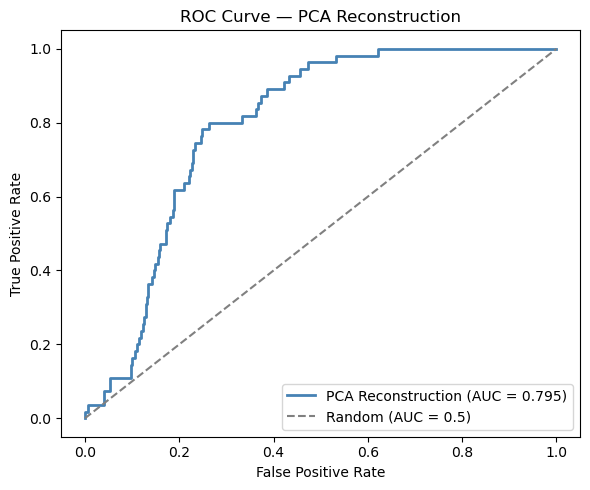

In [12]:
fpr, tpr, _ = roc_curve(true_labels, all_scores)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'PCA Reconstruction (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — PCA Reconstruction')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/pca_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

**Results:**

The ROC curve (AUC = 0.795) confirms the model's weak performance. While it is better than random (0.5), it is significantly below the other models tested on this dataset:

| Model | AUC |
|-------|-----|
| Autoencoder | 0.972 |
| OC-SVM (best config) | 0.947 |
| Isolation Forest | 0.754 |
| kNN | 0.922 |
| **PCA Reconstruction** | **0.795** |

The curve rises slowly at low FPR — the region that matters most in practice, where you want to catch anomalies without flooding the system with false alarms. PCA provides little discriminative power here. It only achieves a reasonably high TPR at high FPR (≥0.2), meaning a useful recall rate would require flagging an unacceptably large fraction of normal samples.

## 11. Why Does PCA Reconstruction Underperform?

PCA reconstruction achieves an AUC of 0.795 and a recall of 0.073 — far below the Autoencoder (AUC 0.972) and OC-SVM (AUC 0.947). The reasons are structural, not incidental.

---

### 1. PCA only penalises distance from a linear subspace

PCA detects anomalies by measuring how far a sample lies **outside** the linear subspace spanned by the top principal components. For this to work, anomalous spectra must be "off-subspace" — they must contain spectral directions that normal spectra do not.

In practice, ambient particles (dust, fibres, environmental debris) tend to produce **broad, relatively featureless Raman spectra** with smooth baselines. These broad features are well-represented by the dominant principal components of the polymer training set, which also capture global intensity trends and broad spectral shapes. The ambient spectra do not occupy a fundamentally different linear subspace — they just sit in a different region of the same space. PCA reconstruction error cannot see this difference.

---

### 2. The subspace is too broad

50 principal components capturing 93.6% of normal variance means the subspace is large. PCA is not compressing the data aggressively — it is retaining a rich, high-dimensional representation of normal structure. The broader the subspace, the more "room" there is for anomalies to reconstruct accurately. Reducing `N_COMPONENTS` increases sensitivity but also increases false positives as even normal samples start reconstructing poorly.

This is a fundamental trade-off PCA cannot escape: on high-dimensional spectral data with complex structure, the normal subspace is inevitably large enough to accommodate many anomalies too.

---

### 3. Other models define boundaries differently

The models that outperform PCA do not rely on subspace distance:

- **OC-SVM** uses an RBF kernel to define a **nonlinear** closed boundary around the normal data in a high-dimensional feature space. Anomalies are outside this boundary regardless of whether they share linear directions with normal data.
- **Autoencoder** uses nonlinear encoder/decoder layers that learn a curved manifold. The bottleneck forces the network to represent only the specific nonlinear patterns it has seen during training; anomalies require combinations of features the network never learned, producing high reconstruction error even when the anomaly spectrum superficially resembles a polymer spectrum in a linear sense.
- **Isolation Forest** and **kNN** operate on local geometry — they detect samples that are isolated or far from their nearest neighbours in the raw feature space, which is a different and often complementary signal to reconstruction error.

---

### Summary

PCA reconstruction is a reasonable first baseline, but it is fundamentally limited to detecting anomalies that are **linearly separable** from normal data. For Raman spectral data where normal and anomalous spectra share broad spectral features and the normal class spans a high-dimensional subspace, this assumption does not hold. Nonlinear models that learn compact, specific representations of normal data — particularly the Autoencoder and OC-SVM — are better suited to this task.